In [1]:
# --- 1. Import Libraries ---
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
# --- 2. Create Synthetic Data (Linearly Separable) ---
print("Step 1: Creating synthetic data...")

# Create 100 data points for two classes
# We use 'make_blobs' to create two distinct clusters
from sklearn.datasets import make_blobs
X, y = make_blobs(n_samples=100, centers=2, n_features=2, random_state=42)

# 'y' is 0 or 1. We reshape it to be a column vector (100, 1)
y = y.reshape(-1, 1)

print(f"Data created: X shape {X.shape}, y shape {y.shape}")

Step 1: Creating synthetic data...
Data created: X shape (100, 2), y shape (100, 1)


In [4]:
# --- 3. Define Helper Function (Sigmoid) ---
print("Step 2: Defining helper functions...")

def sigmoid(z):
    """
    Computes the sigmoid function: 1 / (1 + e^-z)
    """
    return 1 / (1 + np.exp(-z))

Step 2: Defining helper functions...


In [5]:
# --- 4. Set Hyperparameters and Initialize Parameters ---
print("Step 3: Initializing parameters...")

# 'learning_rate' (alpha) controls the step size.
learning_rate = 0.1

# 'epochs' is the number of iterations over the dataset.
epochs = 1000

# 'n_samples' is the number of data points.
# 'n_features' is the number of features (in this case, 2: x1 and x2).
n_samples, n_features = X.shape

# Initialize weights 'w' (one for each feature) and bias 'b'.
# We initialize them to zero.
w = np.zeros((n_features, 1))
b = 0.0

# Create a list to store the 'cost' (error) at each epoch.
cost_history = []

print(f"Starting parameters: w shape {w.shape}, b = {b}")
print(f"Hyperparameters: Learning Rate={learning_rate}, Epochs={epochs}")

Step 3: Initializing parameters...
Starting parameters: w shape (2, 1), b = 0.0
Hyperparameters: Learning Rate=0.1, Epochs=1000


In [6]:
# --- 5. Run Gradient Descent ---
print("Step 4: Running Gradient Descent...")

for epoch in range(epochs):
    
    # --- 5a. Make a Prediction (Forward Pass) ---
    # This is the linear equation: z = X.w + b
    z = np.dot(X, w) + b
    
    # This is the logistic (sigmoid) activation: y_pred = sigmoid(z)
    # y_pred will be a probability between 0 and 1.
    y_pred = sigmoid(z)
    
    # --- 5b. Calculate the Cost (Log Loss / Binary Cross-Entropy) ---
    # This is the cost function for binary classification.
    # We add a small 'epsilon' to prevent log(0), which is undefined.
    epsilon = 1e-9
    cost = -(1/n_samples) * np.sum(y * np.log(y_pred + epsilon) + (1 - y) * np.log(1 - y_pred + epsilon))
    
    # Store the cost for this epoch.
    cost_history.append(cost)
    
    # --- 5c. Calculate the Gradients (Backward Pass) ---
    # 'dw' is the gradient (partial derivative) of the cost with respect to 'w'.
    dw = (1/n_samples) * np.dot(X.T, (y_pred - y))
    
    # 'db' is the gradient (partial derivative) of the cost with respect to 'b'.
    db = (1/n_samples) * np.sum(y_pred - y)
    
    # --- 5d. Update the Parameters ---
    # We update 'w' and 'b' by taking a step in the *opposite* direction of the gradient.
    w = w - learning_rate * dw
    b = b - learning_rate * db
    
    # Optional: Print the cost every 100 epochs.
    if (epoch + 1) % 100 == 0:
        print(f"Epoch {epoch+1}/{epochs} | Cost: {cost:.4f}")

print("Gradient Descent finished.")

Step 4: Running Gradient Descent...
Epoch 100/1000 | Cost: 0.0080
Epoch 200/1000 | Cost: 0.0042
Epoch 300/1000 | Cost: 0.0029
Epoch 400/1000 | Cost: 0.0022
Epoch 500/1000 | Cost: 0.0018
Epoch 600/1000 | Cost: 0.0015
Epoch 700/1000 | Cost: 0.0013
Epoch 800/1000 | Cost: 0.0012
Epoch 900/1000 | Cost: 0.0010
Epoch 1000/1000 | Cost: 0.0010
Gradient Descent finished.


In [7]:
# --- 6. Print Final Parameters ---
print("\n--- Final Results ---")
print(f"Parameters found by model: w = {w.flatten()}, b = {b:.4f}")


--- Final Results ---
Parameters found by model: w = [ 1.83592207 -0.44407001], b = 0.2259



Step 5: Plotting results...


Text(0, 0.5, 'Cost (Error)')

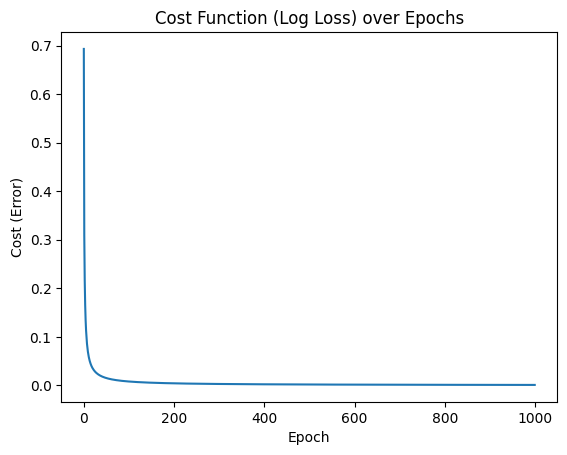

In [8]:
# --- 7. Plot the Results ---
print("\nStep 5: Plotting results...")

# Plot the 'cost_history' list to see if our cost went down.
plt.figure()
plt.plot(cost_history)
plt.title('Cost Function (Log Loss) over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Cost (Error)')

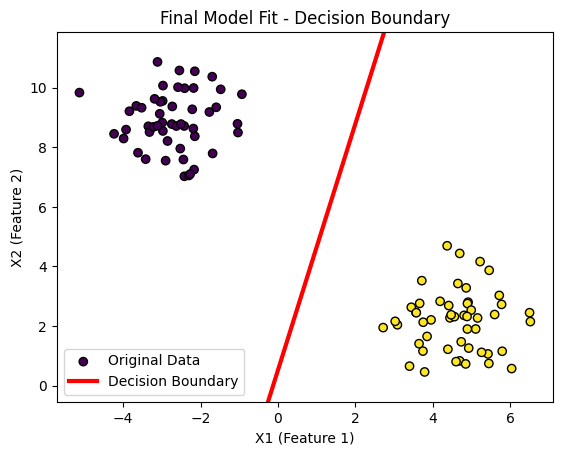

Plotting complete.


In [9]:
# --- 8. Plot the Decision Boundary ---

# Create a final plot with the data and the decision boundary.
# The decision boundary is the line where z = 0 (or sigmoid(z) = 0.5)
# z = w1*x1 + w2*x2 + b = 0
# So, x2 = (-w1*x1 - b) / w2

plt.figure()
# Plot the data points, colored by their class 'y'
# X[:, 0] is the first feature (x1), X[:, 1] is the second feature (x2)
# c=y.ravel() colors the points based on the class (0 or 1)
plt.scatter(X[:, 0], X[:, 1], c=y.ravel(), cmap='viridis', edgecolors='k', label='Original Data')

# Create x1 values for our line
x1_line = np.linspace(np.min(X[:, 0]), np.max(X[:, 0]), 100)

# Calculate the corresponding x2 values for the line
w1 = w[0][0]
w2 = w[1][0]
x2_line = (-w1 * x1_line - b) / w2

# Plot the decision boundary
plt.plot(x1_line, x2_line, color='red', lw=3, label='Decision Boundary')

plt.title('Final Model Fit - Decision Boundary')
plt.xlabel('X1 (Feature 1)')
plt.ylabel('X2 (Feature 2)')
plt.legend()
plt.ylim(np.min(X[:, 1]) - 1, np.max(X[:, 1]) + 1) # Set limits for better visibility
plt.show()

print("Plotting complete.")